In [1]:
import os

import numpy as np
import pandas as pd
import datetime
import xarray as xr

from oceanpy import retrieve_attrs
from emapy.src.readwrite import read_velocity

import matplotlib.pyplot as plt
import cmocean as cmo

In [2]:
global_attrs = {
    "title": "Three EM-APEX floats seeded in the ACC's Polar Front downstream of the South East Indian Ridge",
    "institution": "Institute for Marine and Antarctic Studies, University of Tasmania",
    "references": "https://github.com/southern-ocean-dynamics/ema-seir-pf",
    "comment": (
        "The EM-APEX floats were funded by the Australian Research Council "
        "Discovery Project 24, \"Antarctica's leaky defence to poleward heat "
        "transport\", and deployed in the middle of a CPIES array from the "
        "Southern Ocean Fronts and Eddies (SOFE) project, a collaboration "
        "with the University of Rhode Island funded by NSF (USA) and the "
        "Korea Polar Research Institute (KOPRI, South Korea)."
    ),
    "Conventions": "CF-1.6",
    "instrument": "seabird_ctd_41cp sensor, apluw_ema sensor, iridium9523 device, gps15xh device",
    "featureType": "trajectoryProfile",
}

In [3]:
cruise_id = 'sofe'
float_ids = ['f10761', 'f10762', 'f10763']

In [ ]:
repodir = os.path.dirname(os.getcwd())
print('Repository: ', repodir)
datadir = os.path.join(repodir, 'data')
figsdir = os.path.join(repodir, 'figs')
outdir = os.path.join(repodir, 'output')

savefig = False
savenc = False
if savenc:
    savedir = os.path.join(outdir, 'vel')
    if not os.path.exists(savedir):
        os.makedirs(savedir)

Repository:  /home/jjmeijer/Repos/ema-seir-pf


In [5]:
filedirs = {}
for float_id in float_ids:
    filedirs[float_id] = {
        'dec': os.path.join(datadir, cruise_id, float_id, 'proc', 'dec'),
        'vel': os.path.join(datadir, cruise_id, float_id, 'proc', 'vel')
    }

In [6]:
# columns = P,T,S,u1,v1,verr1,u2,v2,verr2,dpdt,e1mean,e2mean,buoy_pos,timestamp

In [7]:
minp, maxp, dp = 0, 1650, 4
pressure_bins = np.linspace(minp, maxp, int((maxp - minp) / dp) + 1)

def bin_profile(df, pressure_bins):
    """Bin a single descent or ascent dataframe by pressure and return
    the binned T, S, u1, v1, u2, v2 arrays plus the bin midpoints."""
    df = df.copy()
    df['pressure_bin'] = pd.cut(df['P'], bins=pressure_bins)
    df_bin = df.groupby('pressure_bin', observed=False).mean().reset_index()
    pressure = [val.mid for val in df_bin['pressure_bin']]
    return df_bin, pressure

descents = {}
ascents = {}

for float_id in float_ids:

    files = [os.path.join(filedirs[float_id]['vel'], file)
             for file in sorted(os.listdir(filedirs[float_id]['vel']))
             if file.endswith('.txt')]

    descents[float_id], ascents[float_id] = {}, {}
    profiles = []
    t, S = [], []
    u1, v1, verr1, u2, v2, verr2 = [], [], [], [], [], []
    lat, lon, time, cycle = [], [], [], []

    for filename in files:
        header, columns, units, descent_data, ascent_data = read_velocity(filename)

        # load data into dataframes and convert timestamp to datetime
        df_descent = pd.DataFrame(data=descent_data, columns=columns)
        df_descent.index = pd.to_datetime(df_descent['timestamp'], unit='s', origin='unix')
        df_descent = df_descent.drop(columns=['timestamp'])

        df_ascent = pd.DataFrame(data=ascent_data, columns=columns)
        df_ascent.index = pd.to_datetime(df_ascent['timestamp'], unit='s', origin='unix')
        df_ascent = df_ascent.drop(columns=['timestamp'])

        # store raw dataframes in dict
        profile_no = os.path.basename(filename).split('-')[2]
        descents[float_id][profile_no] = df_descent
        ascents[float_id][profile_no] = df_ascent

        # bin descent and ascent separately
        df_descent_bin, pressure = bin_profile(df_descent, pressure_bins)
        df_ascent_bin, _ = bin_profile(df_ascent, pressure_bins)

        # descent -> even index, ascent -> odd index
        profiles.append(int(profile_no))       # descent profile number
        t.append(df_descent_bin['T'].values)
        S.append(df_descent_bin['S'].values)
        u1.append(df_descent_bin['u1'].values)
        v1.append(df_descent_bin['v1'].values)
        verr1.append(df_descent_bin['verr1'].values)
        u2.append(df_descent_bin['u2'].values)
        v2.append(df_descent_bin['v2'].values)
        verr2.append(df_descent_bin['verr2'].values)
        lat.append(float(header['Descent GPS LAT'][0]))
        lon.append(float(header['Descent GPS LON'][0]))
        time.append(datetime.datetime.fromtimestamp(float(header['Descent GPS Timestamp'][0])))
        cycle.append('D')

        profiles.append(int(profile_no))       # ascent profile number (same cast/profile)
        t.append(df_ascent_bin['T'].values)
        S.append(df_ascent_bin['S'].values)
        u1.append(df_ascent_bin['u1'].values)
        v1.append(df_ascent_bin['v1'].values)
        verr1.append(df_ascent_bin['verr1'].values)
        u2.append(df_ascent_bin['u2'].values)
        v2.append(df_ascent_bin['v2'].values)
        verr2.append(df_ascent_bin['verr2'].values)
        lat.append(float(header['Ascent GPS LAT'][0]))
        lon.append(float(header['Ascent GPS LON'][0]))
        time.append(datetime.datetime.fromtimestamp(float(header['Ascent GPS Timestamp'][0])))
        cycle.append('A')


    temperature, salinity = np.asarray(t), np.asarray(S)
    u1, v1, u2, v2 = np.asarray(u1), np.asarray(v1), np.asarray(u2), np.asarray(v2)

    data_vars = dict(
        T=(['profile', 'pressure'], temperature),
        S=(['profile', 'pressure'], salinity),
        u1=(['profile', 'pressure'], u1),
        v1=(['profile', 'pressure'], v1),
        verr1=(['profile', 'pressure'], verr1),
        u2=(['profile', 'pressure'], u2),
        v2=(['profile', 'pressure'], v2),
        verr2=(['profile', 'pressure'], verr2),
    )
    coords = dict(
        station=('profile', profiles),
        pressure=('pressure', pressure),
        longitude=('profile', lon),
        latitude=('profile', lat),
        time=('profile', time),
        cycle=('profile', np.asarray(cycle).astype(str))
    )

    ema_vel = xr.Dataset(data_vars=data_vars, coords=coords)

    # apply global attributes / metadata
    global_attrs["source"] = f"EM-APEX float: {float_id}"
    global_attrs["history"] = "Created " + pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")    
    ema_vel.attrs.update(global_attrs)

    # apply variable attributes / metadata
    variables = ['T', 'S', 'u', 'v'] + ['time', 'latitude', 'longitude', 'pressure']
    attrs_dict = retrieve_attrs(variables)
    apply_map = {'u': ['u1', 'u2'], 'v': ['v1', 'v2']}
    for var, attrs in attrs_dict.items():
        targets = apply_map.get(var, [var])  # default: same name (T, S, time, latitude, ...)
        for target in targets:
            if target in ema_vel.variables:
                ema_vel[target].attrs.update(attrs)
                print(target, attrs)
            else:
                print(f"Warning: '{target}' not found in dataset — skipping")

    if savenc:
        ema_vel.to_netcdf(os.path.join(savedir, 'ema-%s-vel-pgrid.nc' %float_id))
    ema_vel.close()


T {'long_name': 'In-situ Temperature', 'standard_name': 'sea_water_temperature', 'units': 'degree_Celsius'}
S {'long_name': 'Practical Salinity', 'standard_name': 'sea_water_practical_salinity', 'units': 'PSU'}
u1 {'long_name': 'u-velocity component', 'standard_name': 'eastward_sea_water_velocity', 'units': 'm s-1'}
u2 {'long_name': 'u-velocity component', 'standard_name': 'eastward_sea_water_velocity', 'units': 'm s-1'}
v1 {'long_name': 'v-velocity component', 'standard_name': 'northward_sea_water_velocity', 'units': 'm s-1'}
v2 {'long_name': 'v-velocity component', 'standard_name': 'northward_sea_water_velocity', 'units': 'm s-1'}
time {'long_name': 'Time', 'standard_name': 'time'}
latitude {'long_name': 'Latitude', 'standard_name': 'latitude', 'units': 'degree_north'}
longitude {'long_name': 'Longitude', 'standard_name': 'longitude', 'units': 'degree_east'}
pressure {'long_name': 'Pressure', 'standard_name': 'sea_water_pressure', 'units': 'dbar'}
T {'long_name': 'In-situ Temperature

start: 2025-02-16T03:27:11.000000000
end: 2025-03-26T22:17:03.000000000
start: 2025-02-16T03:33:14.000000000
end: 2025-03-26T20:25:48.000000000
start: 2025-02-16T03:07:58.000000000
end: 2025-03-27T05:20:21.000000000


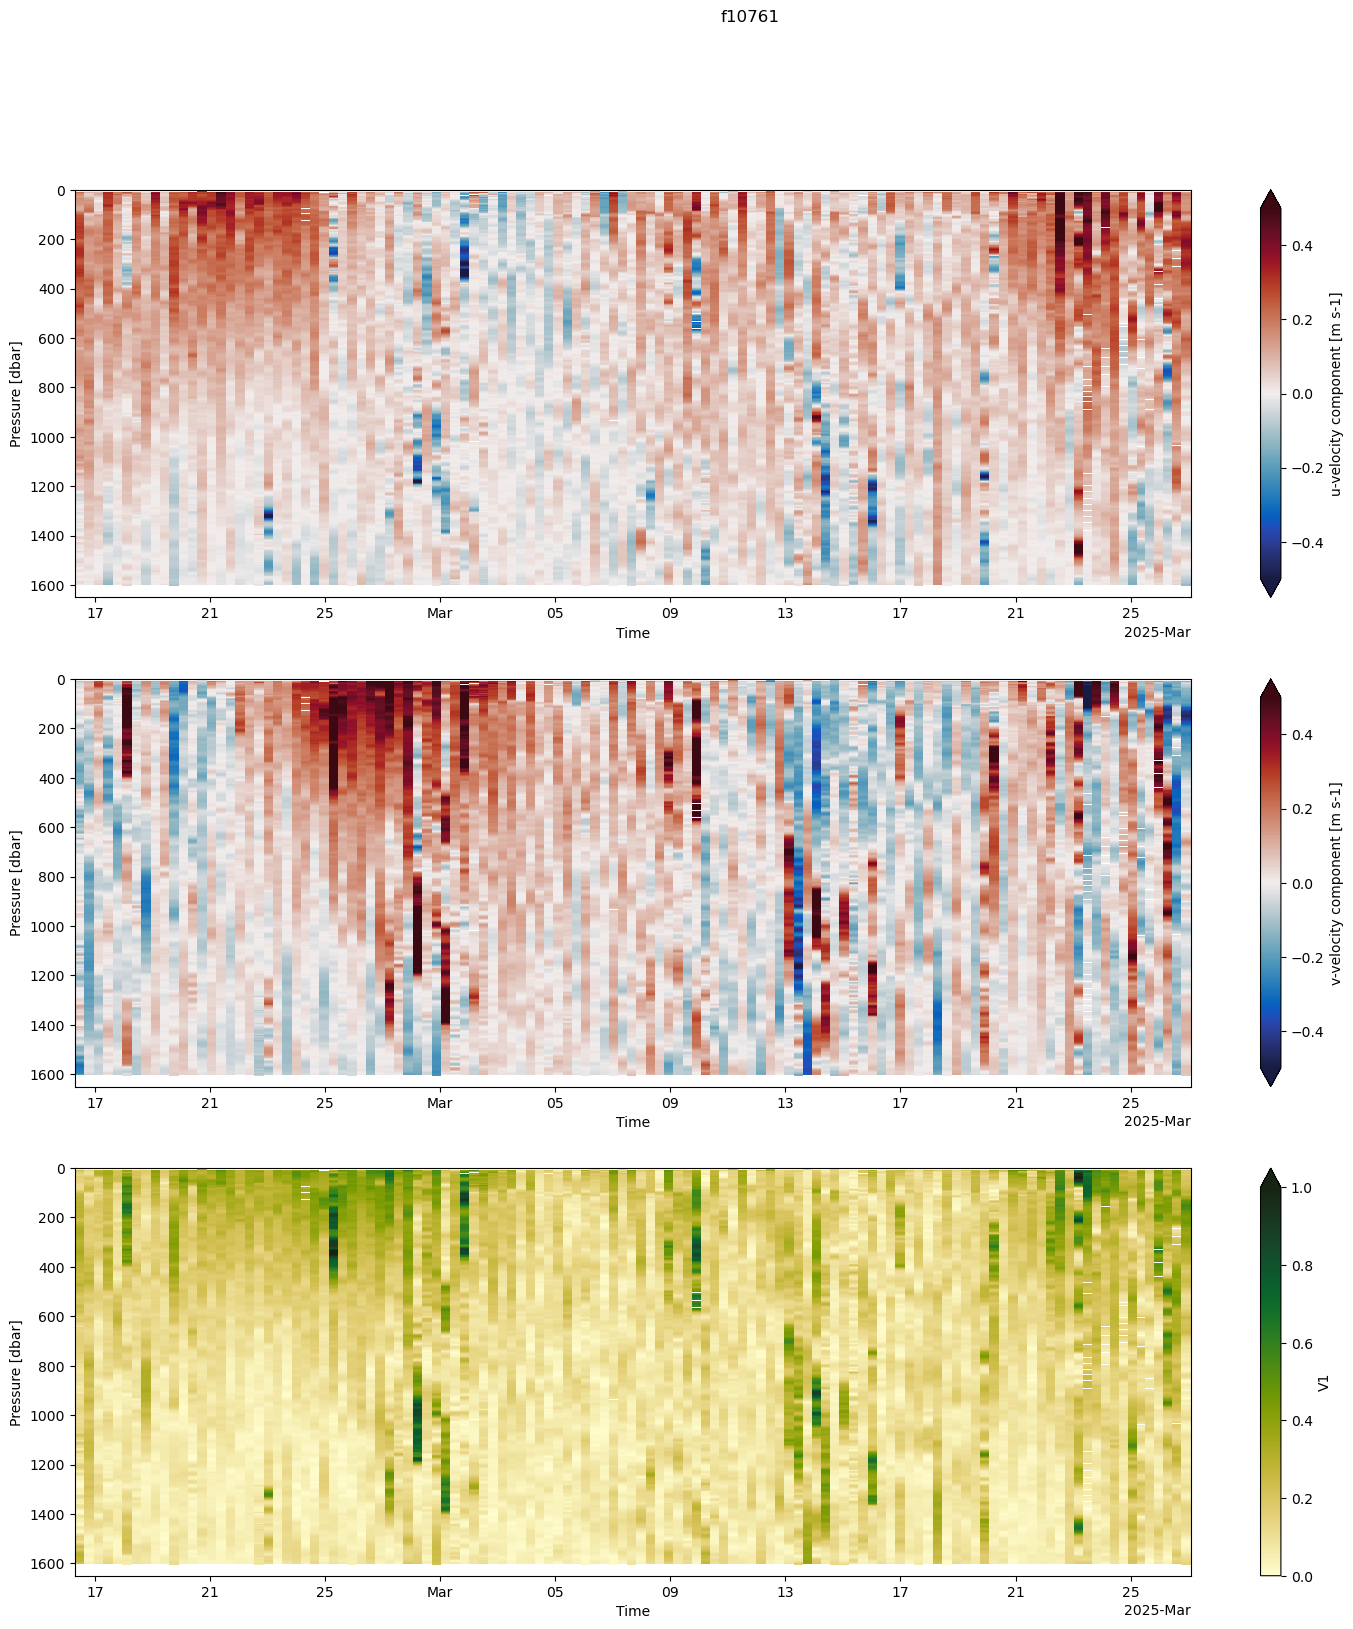

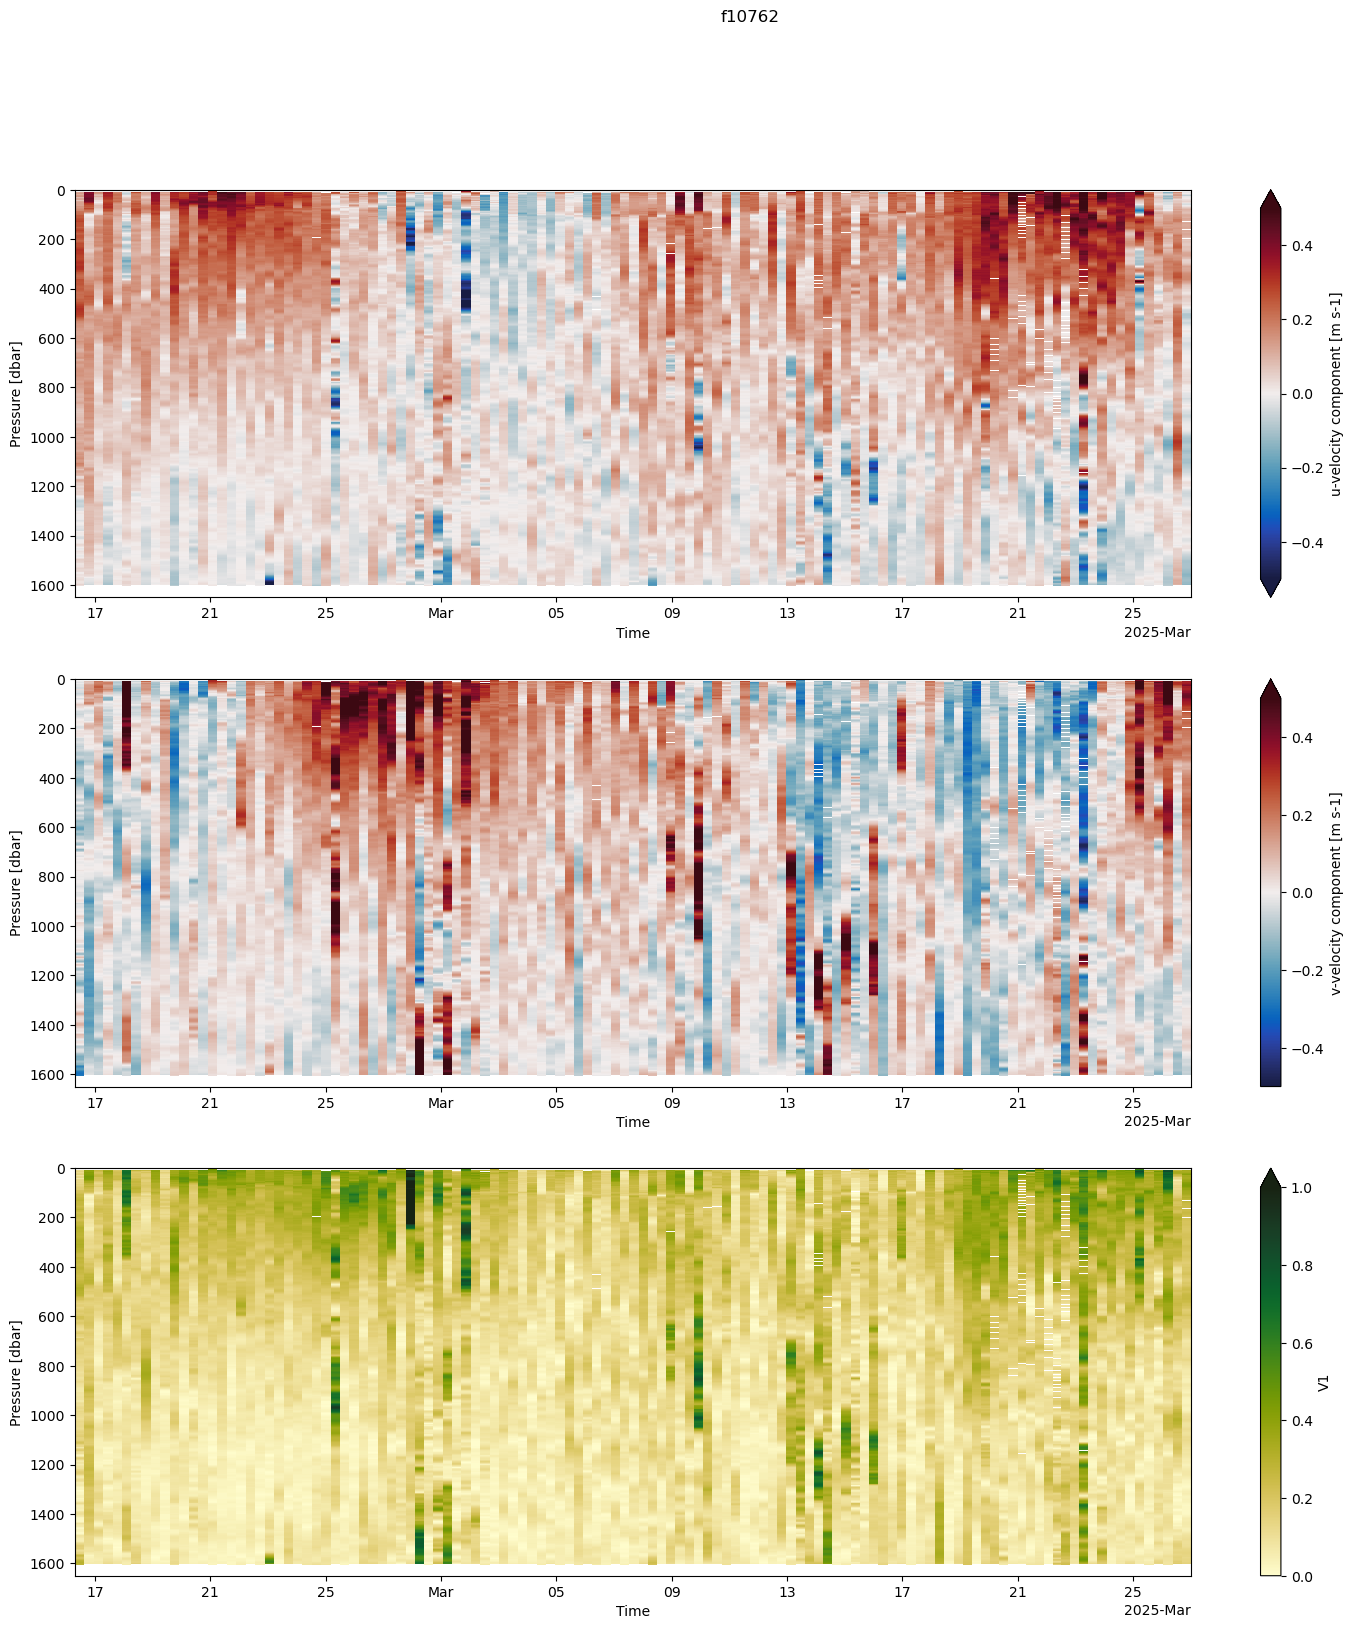

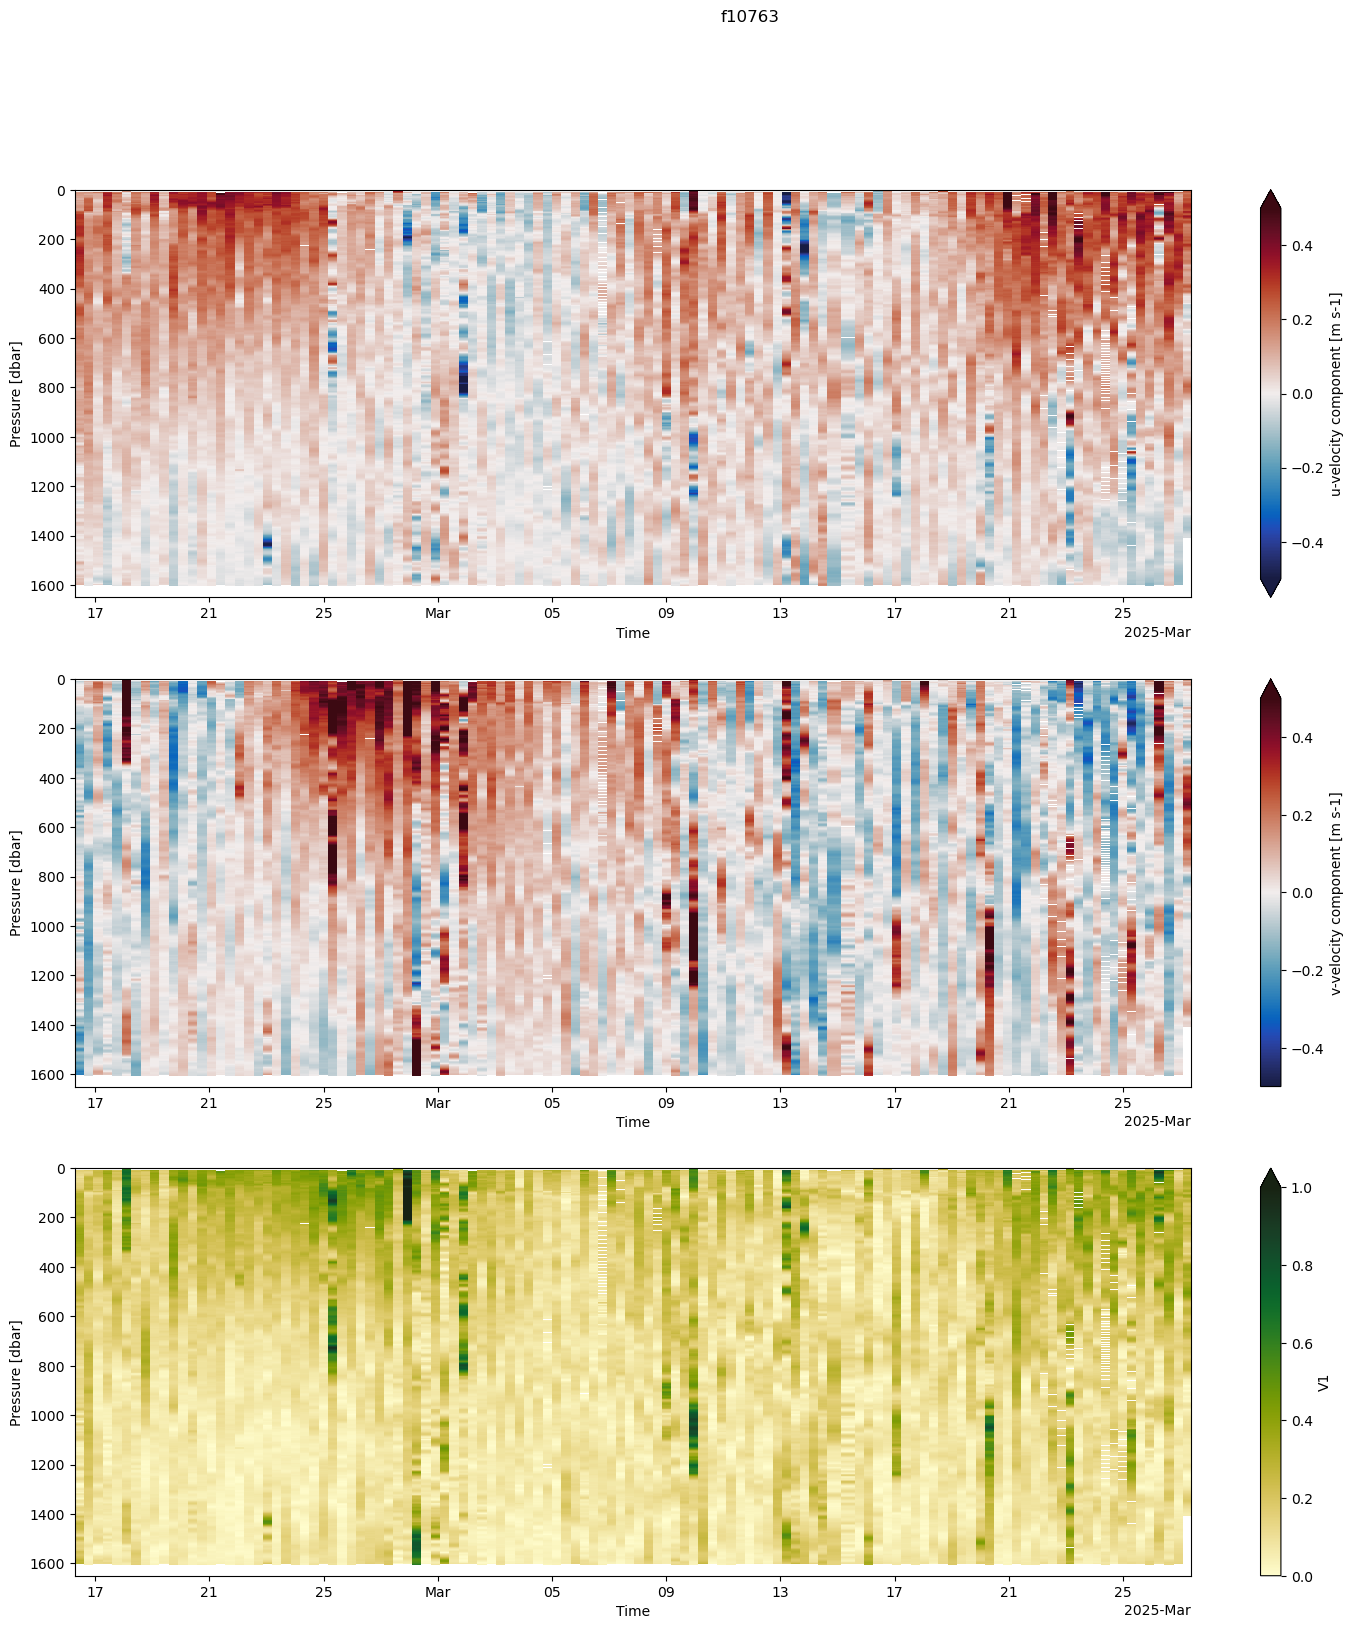

In [8]:
for float_id in float_ids:

    filename = os.path.join(outdir, 'vel', 'ema-%s-vel-pgrid.nc' %float_id)
    vel = xr.open_dataset(filename)

    vel_rapid = vel.isel(profile=slice(0,240))
    vel_rapid['V1'] = np.sqrt(vel_rapid.u1**2 + vel_rapid.v1**2)
    print('start: %s' %vel.time[0].values)
    print('end: %s' %vel_rapid.time[-1].values)

    fig, ax = plt.subplots(nrows=3, figsize=(18,18))
    
    vel_rapid.sel(profile=vel_rapid.cycle == "A").u1.plot(ax=ax[0], x='time', cmap=cmo.cm.balance, vmin=-.5, vmax=.5)
    ax[0].invert_yaxis()
    
    vel_rapid.sel(profile=vel_rapid.cycle == "A").v1.plot(ax=ax[1], x='time', cmap=cmo.cm.balance, vmin=-.5, vmax=.5)
    ax[1].invert_yaxis()

    vel_rapid.sel(profile=vel_rapid.cycle == "A").V1.plot(ax=ax[2], x='time', cmap=cmo.cm.speed, vmin=0, vmax=1)
    ax[2].invert_yaxis()

    fig.suptitle(float_id)

    if savefig:
        fig.savefig(os.path.join(figsdir, '04_uv_speed_on-pgrid_%s.png' %float_id))